In [1]:
%pip install -U langchain-tavily


Note: you may need to restart the kernel to use updated packages.


In [48]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from typing import TypedDict, List, Literal, Annotated
from pydantic import BaseModel, Field

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

from langchain_community.tools import GoogleSerperRun
from langchain_community.utilities import GoogleSerperAPIWrapper

import os


In [49]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0
)

api_wrapper = GoogleSerperAPIWrapper(
    serper_api_key=os.getenv("SERPER_API_KEY"),
    hl="en",
    gl="us",
    type="search"
)

search_tool = GoogleSerperRun(api_wrapper=api_wrapper)
tools = [search_tool]

llm_with_tools = llm.bind_tools(tools)
tool_node = ToolNode(tools)


In [36]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=0
)

api_wrapper = GoogleSerperAPIWrapper(
    serper_api_key=os.getenv("SERPER_API_KEY"),
    hl="en",
    gl="us",
    type="search"
)

search_tool = GoogleSerperRun(api_wrapper=api_wrapper)
tools = [search_tool]

llm_with_tools = llm.bind_tools(tools)
tool_node = ToolNode(tools)


In [ ]:
class ResearchState(TypedDict):
    raw_topic: str
    
    queries: List[str]
    missing_info: str
    final_report: str
    review: str
    messages: Annotated[list, add_messages]


In [51]:
class QuerySchema(BaseModel):
    queries: List[str] = Field(description="Generate 3 targeted search queries")

query_llm = llm.with_structured_output(QuerySchema)

def query_generator(state: ResearchState):
    prompt = f"""
    Topic: {state['raw_topic']}
    Missing information (if any): {state.get('missing_info', 'None')}

    Generate 3 precise web search queries.
    """
    response = query_llm.invoke(prompt)
    return {"queries": response.queries}


In [52]:
def web_researcher(state: ResearchState):
    prompt = f"""
    Use the web search tool to research these queries:
    {state['queries']}
    """
    return {
        "messages": [HumanMessage(content=prompt)]
    }
    
class JudgeSchema(BaseModel):
    verdict: Literal["Gaps Found", "Information Sufficient"]
    missing_info: str = Field(description="What information is missing, if any")

judge_llm = llm.with_structured_output(JudgeSchema)

def reflector(state: ResearchState):
    search_result = state["messages"][-1].content

    prompt = f"""
    Review the research results below.
    Identify if there are knowledge gaps.

    Research:
    {search_result}
    """
    response = judge_llm.invoke(prompt)

    return {
        "review": response.verdict,
        "missing_info": response.missing_info
    }



In [53]:
def judge_condition(state: ResearchState) -> Literal["query", "final"]:
    if state["review"] == "Gaps Found":
        return "query"
    return "final"


In [54]:
def final_writer(state: ResearchState):
    research_content = state["messages"][-1].content

    prompt = f"""
    Write a structured, professional report on:

    Topic: {state['raw_topic']}

    Using the following research:
    {research_content}

    Include:
    - Overview
    - Key impacts
    - Challenges
    - Future outlook
    """
    response = llm.invoke(prompt)
    return {"final_report": response.content}


In [55]:
graph = StateGraph(ResearchState)

graph.add_node("query", query_generator)
graph.add_node("researcher", web_researcher)
graph.add_node("tools", tool_node)
graph.add_node("judge", reflector)
graph.add_node("final", final_writer)

graph.add_edge(START, "query")
graph.add_edge("query", "researcher")

graph.add_conditional_edges(
    "researcher",
    tools_condition
)

graph.add_edge("tools", "judge")

graph.add_conditional_edges("judge", judge_condition)

graph.add_edge("final", END)

workflow = graph.compile()


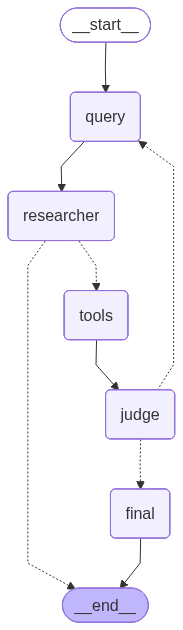

In [56]:
workflow


In [57]:
intial_state = {
    "raw_topic" : "The impact of 2026 AI regulations"
}


In [58]:
final_state = workflow.invoke(intial_state)


In [34]:
final_state


{'raw_topic': 'The impact of 2026 AI regulations',
 'queries': ['2026 AI regulation impact business',
  'future of AI after 2026 regulations',
  'global AI policy 2026 effects'],
 'summary': 'Here\'s a summary of the potential impact of AI regulations around 2026 on businesses and the future of AI, based on the search results for "2026 AI regulation impact business," "future of AI after 2026 regulations," and "global AI policy 2026 effects":\n\n**Overall Impact of 2026 AI Regulations on Businesses:**\n\nThe overarching theme is that AI regulations set to solidify or come into full effect around 2026 will create a more structured, albeit potentially more complex, operating environment for businesses. This will necessitate adaptation and strategic planning.\n\n**Key Impacts on Businesses:**\n\n*   **Increased Compliance Burden and Costs:** Businesses will face new and evolving compliance requirements. This includes understanding and adhering to specific rules regarding data usage, algori